# TrashNet Classification với MobileNetV2
Notebook này train model phân loại rác thải sử dụng Transfer Learning với MobileNetV2

## 1. Import Libraries

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import os
import seaborn as sns

# TensorFlow và Keras
import tensorflow as tf
from tensorflow import keras
from keras.preprocessing.image import ImageDataGenerator
from keras.applications import MobileNetV2
from keras.models import Model
from keras.layers import GlobalAveragePooling2D, Dense, Dropout
from keras.optimizers import Adam
from keras.callbacks import ModelCheckpoint, ReduceLROnPlateau, EarlyStopping

# Evaluation
from sklearn.metrics import classification_report, confusion_matrix
from matplotlib.colors import LinearSegmentedColormap

print(f"TensorFlow version: {tf.__version__}")
# print(f"Keras version: {keras.__version__}")

TensorFlow version: 2.15.0


## 2. Thiết lập Parameters

In [6]:
# Dataset paths
dataset_path = "dataset-augmented"
train_dir = os.path.join(dataset_path, "train")
valid_dir = os.path.join(dataset_path, "valid")
test_dir = os.path.join(dataset_path, "test")

# Image parameters
img_height = 224
img_width = 224
batch_size = 50

# Training parameters
epochs = 100
learning_rate = 0.0001

# Model save path
model_save_path = 'model/mobilenetv2_model.keras'

print("Thiết lập parameters hoàn tất!")

Thiết lập parameters hoàn tất!


## 3. Kiểm tra Dataset

In [7]:
# Kiểm tra số lượng ảnh trong mỗi folder
main_folders = ['train', 'valid', 'test']

for main_folder in main_folders:
    folder_path = os.path.join(dataset_path, main_folder)
    if os.path.isdir(folder_path):
        print(f"\nTrong folder '{main_folder}':")
        garbage_types = os.listdir(folder_path)
        total_images = 0
        for garbage_type in garbage_types:
            subfolder_path = os.path.join(folder_path, garbage_type)
            if os.path.isdir(subfolder_path):
                image_files = [f for f in os.listdir(subfolder_path) if f.lower().endswith(('jpg', 'jpeg', 'png'))]
                num_images = len(image_files)
                total_images += num_images
                print(f"  - {garbage_type}: {num_images} ảnh")
        print(f"  TỔNG: {total_images} ảnh")


Trong folder 'train':
  - glass: 440 ảnh
  - cardboard: 440 ảnh
  - plastic: 440 ảnh
  - paper: 475 ảnh
  - metal: 440 ảnh
  - trash: 440 ảnh
  TỔNG: 2675 ảnh

Trong folder 'valid':
  - glass: 55 ảnh
  - cardboard: 55 ảnh
  - plastic: 55 ảnh
  - paper: 59 ảnh
  - metal: 55 ảnh
  - trash: 55 ảnh
  TỔNG: 334 ảnh

Trong folder 'test':
  - glass: 55 ảnh
  - cardboard: 55 ảnh
  - plastic: 55 ảnh
  - paper: 60 ảnh
  - metal: 55 ảnh
  - trash: 55 ảnh
  TỔNG: 335 ảnh


## 4. Data Augmentation

In [8]:
# Augmentation cho training data
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    vertical_flip=True,
    fill_mode='nearest'
)

# Chỉ rescale cho validation và test data
valid_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

# Tạo data generators
train_dataset = train_datagen.flow_from_directory(
    train_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=True
)

valid_dataset = valid_datagen.flow_from_directory(
    valid_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)

test_dataset = test_datagen.flow_from_directory(
    test_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)

# Hiển thị class labels
class_labels = list(train_dataset.class_indices.keys())
print(f"\nCác class: {class_labels}")
print(f"Class indices: {train_dataset.class_indices}")

Found 2675 images belonging to 6 classes.
Found 334 images belonging to 6 classes.
Found 335 images belonging to 6 classes.

Các class: ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']
Class indices: {'cardboard': 0, 'glass': 1, 'metal': 2, 'paper': 3, 'plastic': 4, 'trash': 5}


## 5. Hiển thị Sample Images

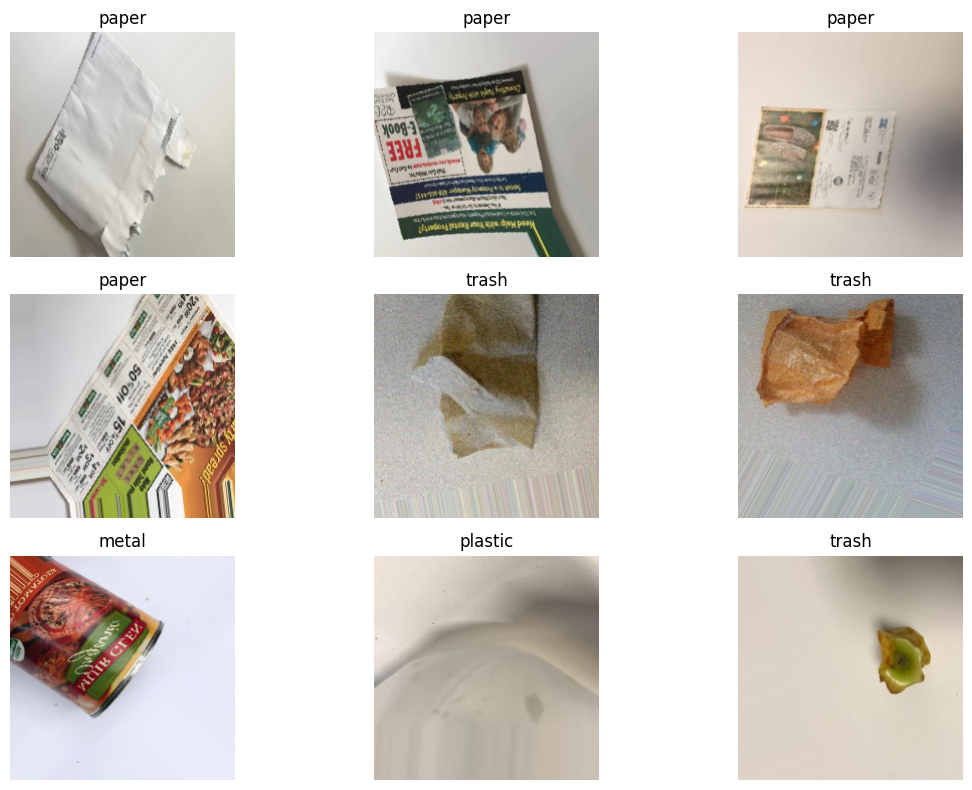

In [9]:
# Hiển thị một số ảnh mẫu từ training dataset
images, labels = next(train_dataset)

plt.figure(figsize=(12, 8))
for i in range(9):
    label_idx = np.argmax(labels[i])
    label_name = class_labels[label_idx]
    
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(images[i])
    plt.title(label_name)
    plt.axis('off')

plt.tight_layout()
plt.show()

## 6. Xây dựng MobileNetV2 Model

In [10]:
# Load MobileNetV2 pretrained trên ImageNet
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(img_height, img_width, 3)
)

# Freeze các layer đầu (layer 0-99)
for layer in base_model.layers[:100]:
    layer.trainable = False

# Unfreeze các layer sau (layer 100-153)
for layer in base_model.layers[100:]:
    layer.trainable = True

# Thêm custom layers
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.5)(x)
predictions = Dense(6, activation='softmax')(x)

# Tạo model hoàn chỉnh
model = Model(inputs=base_model.input, outputs=predictions)

print("Model đã được xây dựng!")
print(f"Tổng số layers: {len(model.layers)}")
print(f"Số layers trainable: {sum([1 for layer in model.layers if layer.trainable])}")

2026-04-15 13:31:08.900425: W tensorflow/core/common_runtime/gpu/gpu_device.cc:2256] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


9406464/9406464 [==============================] - 0s 0us/step
Model đã được xây dựng!
Tổng số layers: 157
Số layers trainable: 57


In [11]:
# Hiển thị model summary
model.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 224, 224, 3)]        0         []                            
                                                                                                  
 Conv1 (Conv2D)              (None, 112, 112, 32)         864       ['input_1[0][0]']             
                                                                                                  
 bn_Conv1 (BatchNormalizati  (None, 112, 112, 32)         128       ['Conv1[0][0]']               
 on)                                                                                              
                                                                                                  
 Conv1_relu (ReLU)           (None, 112, 112, 32)         0         ['bn_Conv1[0][0]']        

## 7. Compile Model

In [12]:
# Compile model
model.compile(
    optimizer=Adam(learning_rate=learning_rate),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Model đã được compile!")

Model đã được compile!


## 8. Thiết lập Callbacks

In [13]:
# Model Checkpoint - lưu model tốt nhất
checkpoint = ModelCheckpoint(
    filepath=model_save_path,
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

# Reduce Learning Rate - giảm learning rate khi val_accuracy không cải thiện
reduce_lr = ReduceLROnPlateau(
    monitor='val_accuracy',
    factor=0.5,
    patience=5,
    min_lr=1e-7,
    verbose=1
)

# Early Stopping - dừng training khi không còn cải thiện
early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

callbacks = [checkpoint, reduce_lr, early_stop]

print("Callbacks đã được thiết lập!")

Callbacks đã được thiết lập!


## 9. Training Model

In [14]:
# Train model
print("Bắt đầu training...\n")

history = model.fit(
    train_dataset,
    validation_data=valid_dataset,
    epochs=epochs,
    callbacks=callbacks,
    verbose=1
)

print("\nTraining hoàn tất!")

Bắt đầu training...

Epoch 1/100
54/54 [==============================] - ETA: 0s - loss: 1.3738 - accuracy: 0.4744
Epoch 1: val_accuracy improved from -inf to 0.44611, saving model to model/mobilenetv2_model.keras
54/54 [==============================] - 29s 476ms/step - loss: 1.3738 - accuracy: 0.4744 - val_loss: 1.4466 - val_accuracy: 0.4461 - lr: 1.0000e-04
Epoch 2/100
54/54 [==============================] - ETA: 0s - loss: 0.7904 - accuracy: 0.7047
Epoch 2: val_accuracy did not improve from 0.44611
54/54 [==============================] - 24s 444ms/step - loss: 0.7904 - accuracy: 0.7047 - val_loss: 2.1645 - val_accuracy: 0.3503 - lr: 1.0000e-04
Epoch 3/100
54/54 [==============================] - ETA: 0s - loss: 0.5663 - accuracy: 0.7921
Epoch 3: val_accuracy did not improve from 0.44611
54/54 [==============================] - 24s 445ms/step - loss: 0.5663 - accuracy: 0.7921 - val_loss: 2.1305 - val_accuracy: 0.3713 - lr: 1.0000e-04
Epoch 4/100
54/54 [===========================

## 10. Visualize Training History

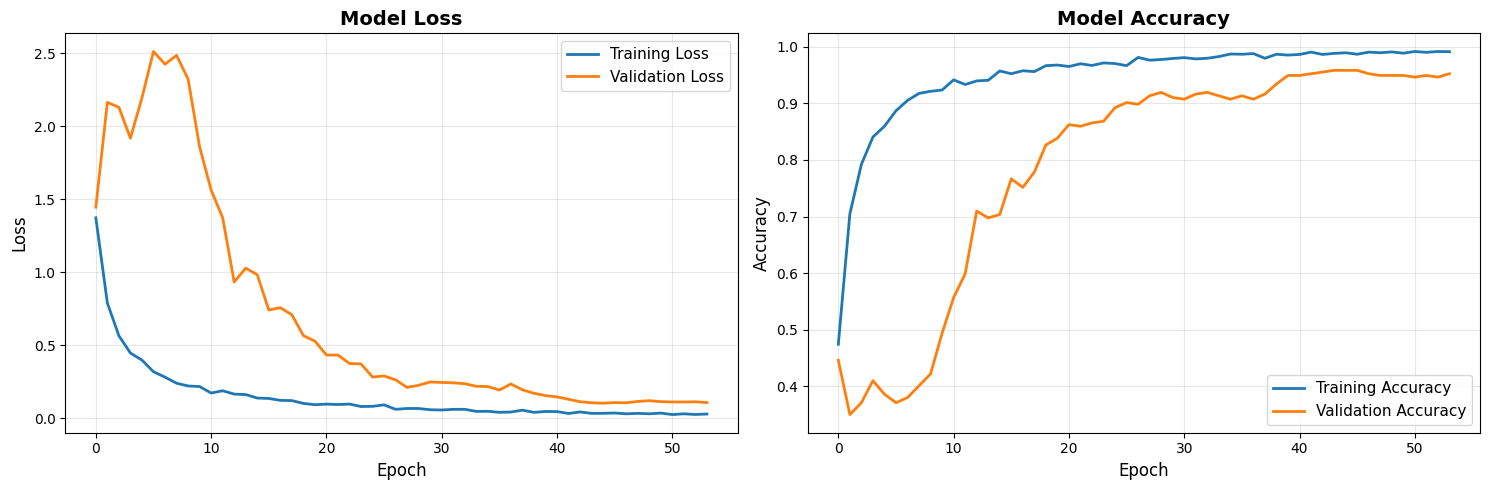


Kết quả tốt nhất tại epoch 44:
  - Training Accuracy: 0.9880
  - Validation Accuracy: 0.9581
  - Training Loss: 0.0348
  - Validation Loss: 0.1075


In [15]:
# Vẽ đồ thị Loss và Accuracy
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Loss plot
axes[0].plot(history.history['loss'], label='Training Loss', linewidth=2)
axes[0].plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
axes[0].set_title('Model Loss', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss', fontsize=12)
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# Accuracy plot
axes[1].plot(history.history['accuracy'], label='Training Accuracy', linewidth=2)
axes[1].plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
axes[1].set_title('Model Accuracy', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Accuracy', fontsize=12)
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# In kết quả tốt nhất
best_epoch = np.argmax(history.history['val_accuracy'])
print(f"\nKết quả tốt nhất tại epoch {best_epoch + 1}:")
print(f"  - Training Accuracy: {history.history['accuracy'][best_epoch]:.4f}")
print(f"  - Validation Accuracy: {history.history['val_accuracy'][best_epoch]:.4f}")
print(f"  - Training Loss: {history.history['loss'][best_epoch]:.4f}")
print(f"  - Validation Loss: {history.history['val_loss'][best_epoch]:.4f}")

## 11. Đánh giá Model trên Validation Set

In [16]:
# Load model tốt nhất
best_model = keras.models.load_model(model_save_path)

# Đánh giá trên validation set
val_loss, val_accuracy = best_model.evaluate(valid_dataset, verbose=0)
print(f"Validation Loss: {val_loss:.4f}")
print(f"Validation Accuracy: {val_accuracy:.4f}")

Validation Loss: 0.1075
Validation Accuracy: 0.9581


## 12. Classification Report và Confusion Matrix

7/7 [==============================] - 2s 144ms/step

CLASSIFICATION REPORT
              precision    recall  f1-score   support

   cardboard       0.98      0.91      0.94        55
       glass       0.98      0.95      0.96        55
       metal       0.92      1.00      0.96        55
       paper       0.95      0.97      0.96        59
     plastic       0.96      0.95      0.95        55
       trash       0.96      0.98      0.97        55

    accuracy                           0.96       334
   macro avg       0.96      0.96      0.96       334
weighted avg       0.96      0.96      0.96       334



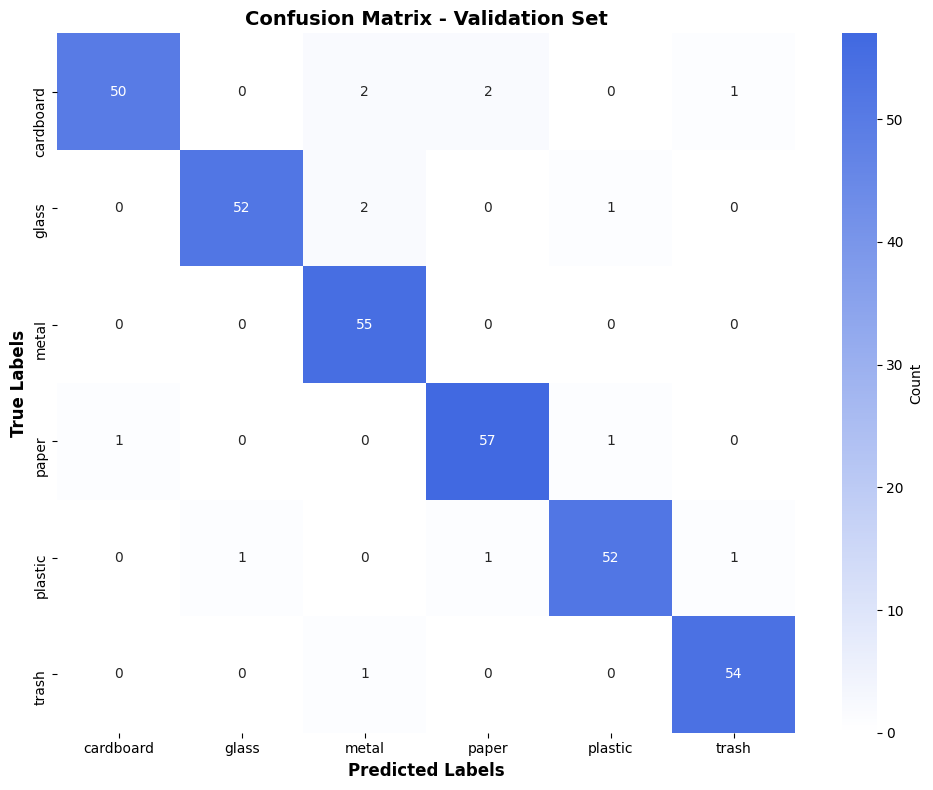

In [17]:
# Lấy predictions
y_pred = best_model.predict(valid_dataset, verbose=1)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = valid_dataset.classes

# Classification Report
print("\n" + "="*60)
print("CLASSIFICATION REPORT")
print("="*60)
print(classification_report(y_true, y_pred_classes, target_names=class_labels))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred_classes)

# Vẽ Confusion Matrix
colors = ["white", "royalblue"]
cmap_cm = LinearSegmentedColormap.from_list("cmap_cm", colors)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap=cmap_cm, 
            xticklabels=class_labels, yticklabels=class_labels,
            cbar_kws={'label': 'Count'})
plt.xlabel('Predicted Labels', fontsize=12, fontweight='bold')
plt.ylabel('True Labels', fontsize=12, fontweight='bold')
plt.title('Confusion Matrix - Validation Set', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 13. Visualize Predictions

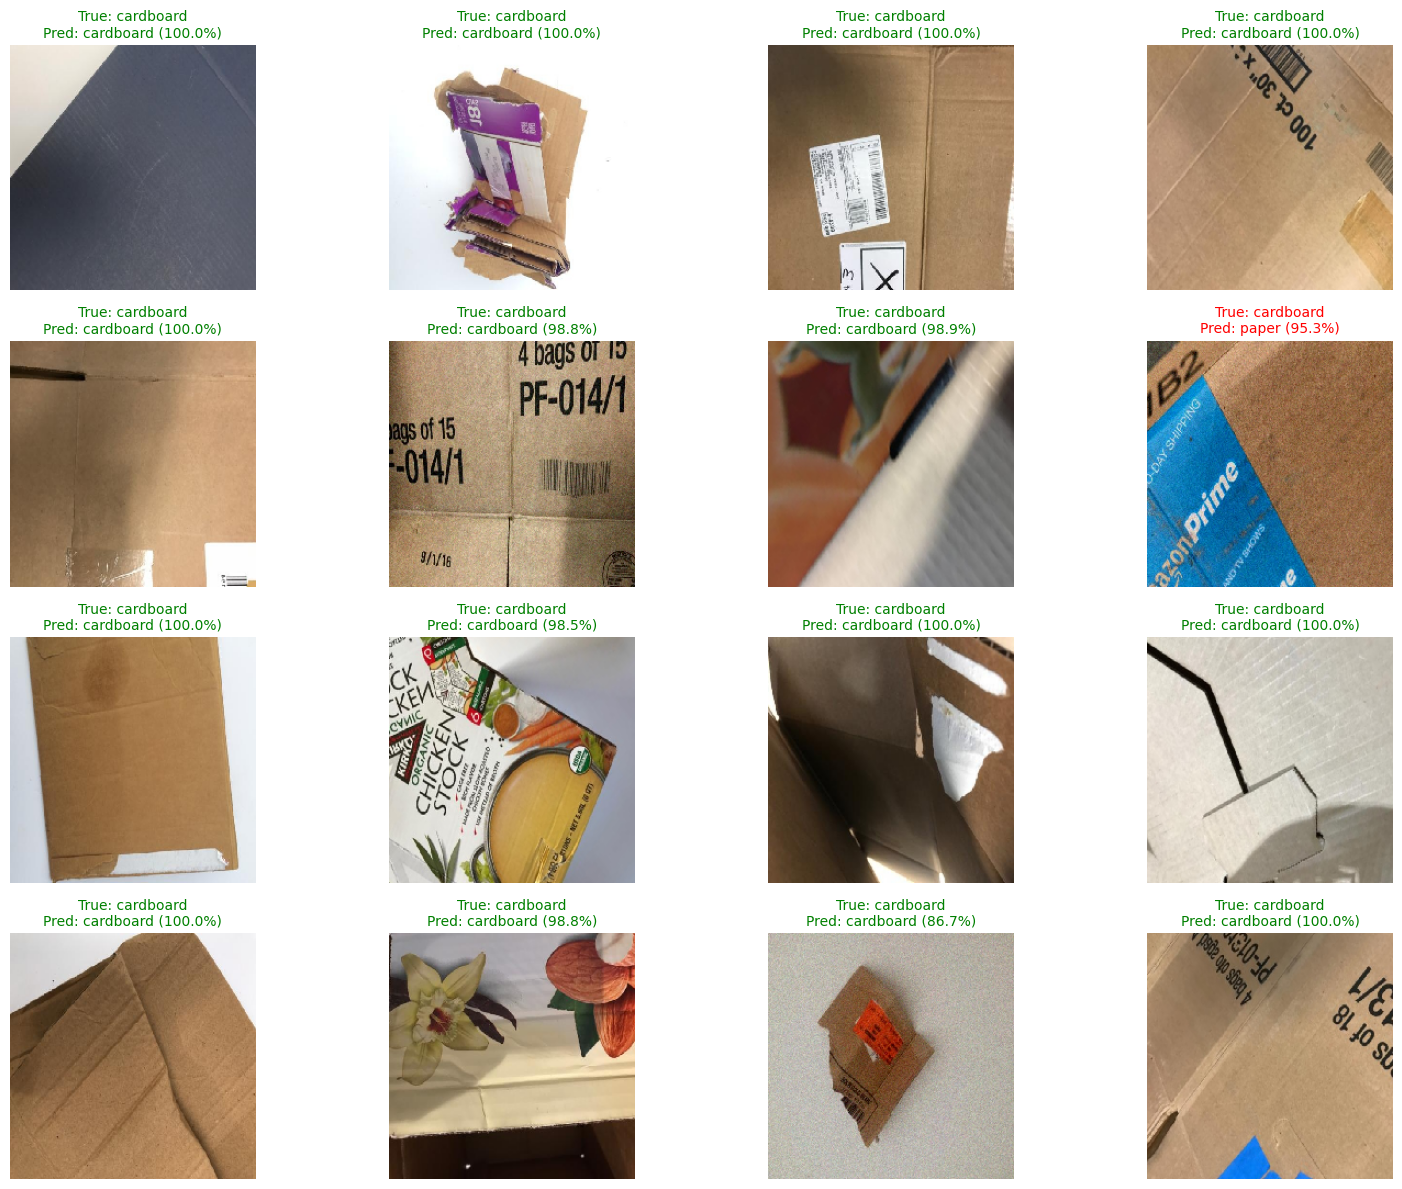

In [18]:
# Lấy một batch từ validation set
images, labels = next(valid_dataset)
predictions = best_model.predict(images, verbose=0)

# Hiển thị kết quả predictions
plt.figure(figsize=(16, 12))
for i in range(min(16, len(images))):
    ax = plt.subplot(4, 4, i + 1)
    plt.imshow(images[i])
    
    true_label = class_labels[np.argmax(labels[i])]
    pred_label = class_labels[np.argmax(predictions[i])]
    confidence = np.max(predictions[i]) * 100
    
    # Màu xanh nếu đúng, màu đỏ nếu sai
    color = 'green' if true_label == pred_label else 'red'
    
    plt.title(f"True: {true_label}\nPred: {pred_label} ({confidence:.1f}%)",
              color=color, fontsize=10)
    plt.axis('off')

plt.tight_layout()
plt.show()

## 14. Test trên Test Set

In [19]:
# Đánh giá trên test set
test_loss, test_accuracy = best_model.evaluate(test_dataset, verbose=1)
print(f"\nTest Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

# Predictions trên test set
y_test_pred = best_model.predict(test_dataset, verbose=1)
y_test_pred_classes = np.argmax(y_test_pred, axis=1)
y_test_true = test_dataset.classes

# Classification Report cho test set
print("\n" + "="*60)
print("TEST SET - CLASSIFICATION REPORT")
print("="*60)
print(classification_report(y_test_true, y_test_pred_classes, target_names=class_labels))

7/7 [==============================] - 1s 139ms/step - loss: 0.2041 - accuracy: 0.9493

Test Loss: 0.2041
Test Accuracy: 0.9493
7/7 [==============================] - 1s 140ms/step

TEST SET - CLASSIFICATION REPORT
              precision    recall  f1-score   support

   cardboard       1.00      0.91      0.95        55
       glass       0.96      0.91      0.93        55
       metal       0.93      1.00      0.96        55
       paper       0.91      0.98      0.94        60
     plastic       0.94      0.89      0.92        55
       trash       0.96      1.00      0.98        55

    accuracy                           0.95       335
   macro avg       0.95      0.95      0.95       335
weighted avg       0.95      0.95      0.95       335



## 15. Tóm tắt Kết quả

In [20]:
print("\n" + "="*60)
print("TÓM TẮT KẾT QUẢ MODEL")
print("="*60)
print(f"Model Architecture: MobileNetV2 (Transfer Learning)")
print(f"Input Shape: {img_height}x{img_width}x3")
print(f"Number of Classes: {len(class_labels)}")
print(f"Classes: {class_labels}")
print(f"\nTraining Set Size: {train_dataset.n} images")
print(f"Validation Set Size: {valid_dataset.n} images")
print(f"Test Set Size: {test_dataset.n} images")
print(f"\nBest Validation Accuracy: {max(history.history['val_accuracy']):.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"\nModel saved at: {model_save_path}")
print("="*60)


TÓM TẮT KẾT QUẢ MODEL
Model Architecture: MobileNetV2 (Transfer Learning)
Input Shape: 224x224x3
Number of Classes: 6
Classes: ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']

Training Set Size: 2675 images
Validation Set Size: 334 images
Test Set Size: 335 images

Best Validation Accuracy: 0.9581
Test Accuracy: 0.9493

Model saved at: model/mobilenetv2_model.keras
